# Notebook to generate star list for pointing/alignment data
Author: Zach Curtis-Ginsberg
Updated: June 3rd, 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import AltAz, EarthLocation, SkyCoord, get_body, get_sun
from astropy.time import Time
from astropy.visualization import quantity_support
import pandas as pd
from tqdm import tqdm, trange
from astroquery.simbad import Simbad
from scipy.optimize import curve_fit
from scipy.interpolate import make_interp_spline, PchipInterpolator, make_splrep
import time

In [2]:
# Load site information
psct = EarthLocation(lat=31.674761*u.deg,lon=-110.952795*u.deg,height=1271*u.m)
utcoffset = -7 * u.hour
date = Time(time.time(), format='unix').iso

# If the time is greater than noon UTC (3am local), go to the next day Arizona midnight, else today Arizona midnight
if int(date[11:13]) > 12:
    day = int(date[8:10]) + 1
    date = Time(f'{date[:8]}{day} 06:00:00.00')
else:
    date = Time(f'{date[:10]} 06:00:00.00')

In [3]:
# Get list of stars with a certain (V band) magnitude
# This can take a long time if the database is not cached
simbad = Simbad()
simbad.add_votable_fields("V")
stars = simbad.query_catalog("HIP", criteria="V<=4.5") # if you want it to be within certain values can do something like criteria="4.0<=V AND V<=4.5"

alt_limit = 30

star_sources = []
star_mags = []
star_az_alts = []
for n, star in tqdm(enumerate(stars), total=len(stars)):
    _source = SkyCoord.from_name(star['main_id'])
    altaz = _source.transform_to(AltAz(obstime=date, location=psct))
    _alt = altaz.alt.value
    _az = altaz.az.value
    if _alt < alt_limit:
        continue
    star_sources.append(_source)
    star_mags.append(star['V'])
    star_az_alts.append((_az, _alt))
star_alt_az = np.array(star_az_alts)

100%|██████████| 893/893 [00:03<00:00, 281.92it/s]


In [4]:
num_azs = 10
num_alts = 10

grid = []
alts = np.linspace(alt_limit, 90, num_alts, endpoint=True)
azs = np.linspace(0, 360, num_azs, endpoint=False) #* 1/np.cos(alts*np.pi/180)
for n, az in enumerate(azs):
    for m, alt in enumerate(alts):
        grid.append((az, alt))
grid = np.array(grid)

grid_stars = []
grid_az_alts = []
grid_mags = []

for grid_loc in grid:
    distances = np.linalg.norm(star_az_alts-grid_loc, axis=1) 
    min_index = np.argmin(distances)
    if stars[min_index] in grid_stars:
        continue
    grid_stars.append(stars[min_index])
    grid_az_alts.append(star_az_alts[min_index])
    grid_mags.append(star_mags[min_index])

In [5]:
for n, star, az_alt, mag in zip(range(len(grid_stars)), grid_stars, grid_az_alts, grid_mags):
    _name = star['main_id']
    _src = SkyCoord.from_name(_name)
    _ra = _src.ra
    _dec = _src.dec
    #print(f'{_name}: {_ra:.2f}° RA, {_dec:.2f}° Dec')
    print(f'{_name}:', _ra, 'RA,', _dec, 'Dec')

* alf Ori: 88d47m34.580364s RA, 7d24m25.4304s Dec
* pi. Sco: 239d42m46.698552s RA, -26d06m50.78862s Dec
* pi. Sgr: 287d26m27.493908s RA, -21d01m25.010328s Dec
* bet Lup: 224d37m58.88046s RA, -43d08m02.26986s Dec
* gam Cen: 190d22m45.601212s RA, -48d57m35.537472s Dec
* tau Sco: 248d58m14.292804s RA, -28d12m57.661524s Dec
* alf02 CVn: 194d00m24.98382s RA, 38d19m06.155184s Dec
* del Ori: 83d00m06.001416s RA, -0d17m56.742396s Dec
* gam02 Vel: 122d22m59.252016s RA, -47d20m11.710788s Dec
* gam Crv: 183d57m05.562144s RA, -17d32m30.949656s Dec
* zet Her: 250d19m17.415588s RA, 31d36m09.78732s Dec
* alf Hyi: 29d41m32.07876s RA, -61d34m11.35974s Dec
* sig Sgr: 283d48m58.897476s RA, -26d17m48.206796s Dec
* zet01 UMa: 200d58m53.134212s RA, 54d55m31.295568s Dec
* tau Pup: 102d29m02.537196s RA, -50d36m52.33932s Dec
* bet01 Sco: 241d21m33.479748s RA, -19d48m19.630008s Dec
* alf Ari: 31d47m36.08556s RA, 23d27m44.70318s Dec
* eps Sgr: 276d02m34.77606s RA, -34d23m04.619364s Dec
* alf Tuc: 334d37m31.68656

57 stars
100 grid points


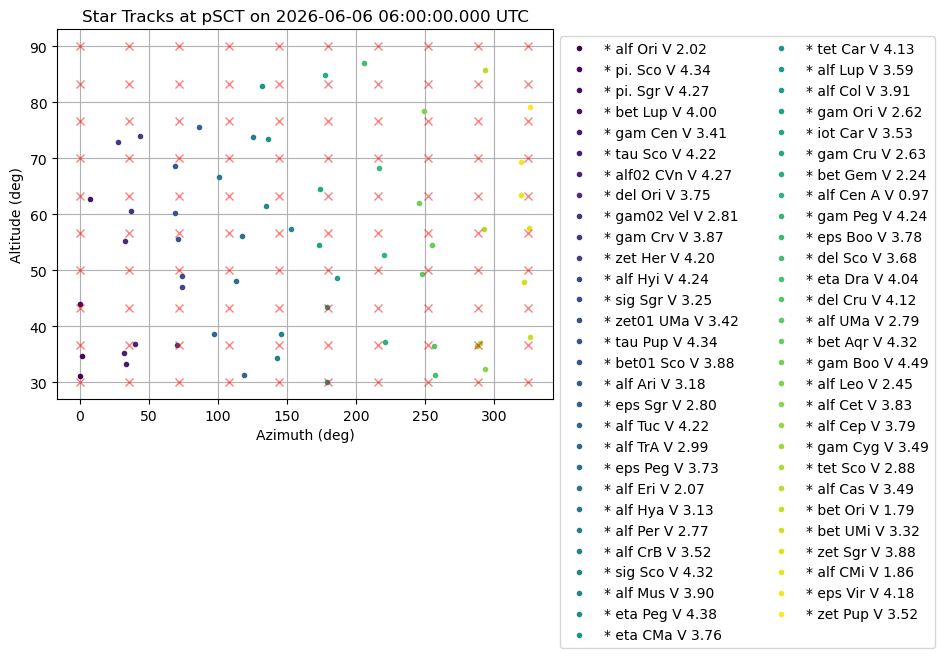

In [6]:
cmap = plt.get_cmap('viridis', len(grid_stars))
a = 0
for n, star, az_alt, mag in zip(range(len(grid_stars)), grid_stars, grid_az_alts, grid_mags):
    az, alt = az_alt
    plt.plot(az, alt, '.', color=cmap(n), label=f'{star['main_id']} V {mag:.2f}')
    a += 1
print(a, 'stars')
a = 0
for grid_point in grid:
    grid_az, grid_alt = grid_point
    plt.plot(grid_az, grid_alt, 'x', color='r', alpha=0.5)
    a += 1
print(a, 'grid points')
plt.plot([], [], 'x', color='r', alpha=0.5)#, label='Grid Points')
plt.legend(bbox_to_anchor=(1,1), ncols=2)
#plt.legend()
plt.xlabel('Azimuth (deg)')
plt.ylabel('Altitude (deg)')
plt.title(f'Star Tracks at pSCT on {date} UTC')
plt.grid(which='both')
plt.show()

# Adding time

In [152]:
delta_night = np.arange(-7*60, 7*60, 3)/60*u.hour
times_night = date + delta_night
frame_night = AltAz(obstime=times_night, location=psct)
sunaltazs = get_sun(times_night).transform_to(frame_night)

In [153]:
ind_night_start = np.where(sunaltazs.alt.deg < -18)[0][0]
ind_night_end = np.where(sunaltazs.alt.deg < -18)[0][-1]
times_dark = times_night[ind_night_start:ind_night_end+1]

In [154]:
# Get list of stars with a certain (V band) magnitude
# This can take a long time if the database is not cached
simbad = Simbad()
simbad.add_votable_fields("V")
stars = simbad.query_catalog("HIP", criteria="V<=4.5") # if you want it to be within certain values can do something like criteria="4.0<=V AND V<=4.5"

alt_limit = 45

# sort stars by azimuth at the beginning of the night before grid selection
star_names = [None for i in range(len(stars))]
star_sources = [None for i in range(len(stars))]
star_mags = [None for i in range(len(stars))]
star_azs = [None for i in range(len(stars))]
for n, star in tqdm(enumerate(stars), total=len(stars)):
    _name = star['main_id']
    _source = SkyCoord.from_name(_name)
    altaz = _source.transform_to(AltAz(obstime=times_dark[0], location=psct))
    _az = altaz.az.deg
    star_azs[n] = _az
    star_names[n] = _name
    star_sources[n] = _source
    star_mags[n] = star['V']

order_list = [star_azs.index(a) for a in sorted(star_azs)]
star_names = [star_names[n] for n in order_list]
star_mags = [star_mags[n] for n in order_list]
star_sources = [star_sources[n] for n in order_list]

100%|██████████| 893/893 [00:03<00:00, 233.96it/s]


In [155]:
num_azs = 30
num_alts = 5
grid = []
grid_alts = np.linspace(alt_limit, 90, num_alts, endpoint=False)
#azs = np.linspace(0, 360, num_azs, endpoint=False)
for alt in grid_alts:
    grid_azs = np.linspace(0, 360, int(np.round(num_azs * np.cos(alt*np.pi/180))), endpoint=False)
    for az in grid_azs:
        grid.append((az, alt))
grid = np.array(grid)
grid_stars = [None for i in grid]
grid_az_alts = [None for i in grid]
grid_mags = [None for i in grid]
grid_times = [None for i in grid]
min_distances = np.ones(len(grid)) * np.inf

for n, star_name, star_source, star_mag in tqdm(zip(range(len(star_names)), star_names, star_sources, star_mags), total=len(star_names)):
    altazs = star_source.transform_to(AltAz(obstime=times_dark, location=psct))
    _azs = altazs.az.deg
    _alts = altazs.alt.deg
    if np.max(_alts) < alt_limit:
        continue
    _azalts = np.array([(_az, _alt) for _az, _alt in zip(_azs, _alts)])
    distances = np.zeros(len(grid))
    times_min = [None] * len(grid)
    _az_alts = [None] * len(grid)
    for m, grid_loc in enumerate(grid):
        distance = np.linalg.norm(_azalts-grid_loc, axis=1)
        min_index = np.argmin(distance)
        distances[m] = distance[min_index]
        times_min[m] = times_dark[min_index]
        _az_alts[m] = _azalts[min_index]
    else:
        for m, dist, _min, _time, azalt in zip(range(len(grid)), distances, min_distances, times_min, _az_alts):
            choice = np.min([dist, _min])
            if choice == dist:
                if _time not in grid_times:
                    grid_az_alts[m] = azalt
                    grid_mags[m] = star_mag
                    grid_stars[m] = star_name
                    grid_times[m] = _time
                    min_distances[m] = dist

# Re-order the list of stars by their observation time
order_list = [grid_times.index(a) for a in sorted(grid_times)]
grid_stars = [grid_stars[n] for n in order_list]
grid_mags = [grid_mags[n] for n in order_list]
grid_az_alts = [grid_az_alts[n] for n in order_list]
grid_times = [grid_times[n] for n in order_list]

100%|██████████| 893/893 [00:16<00:00, 54.57it/s]


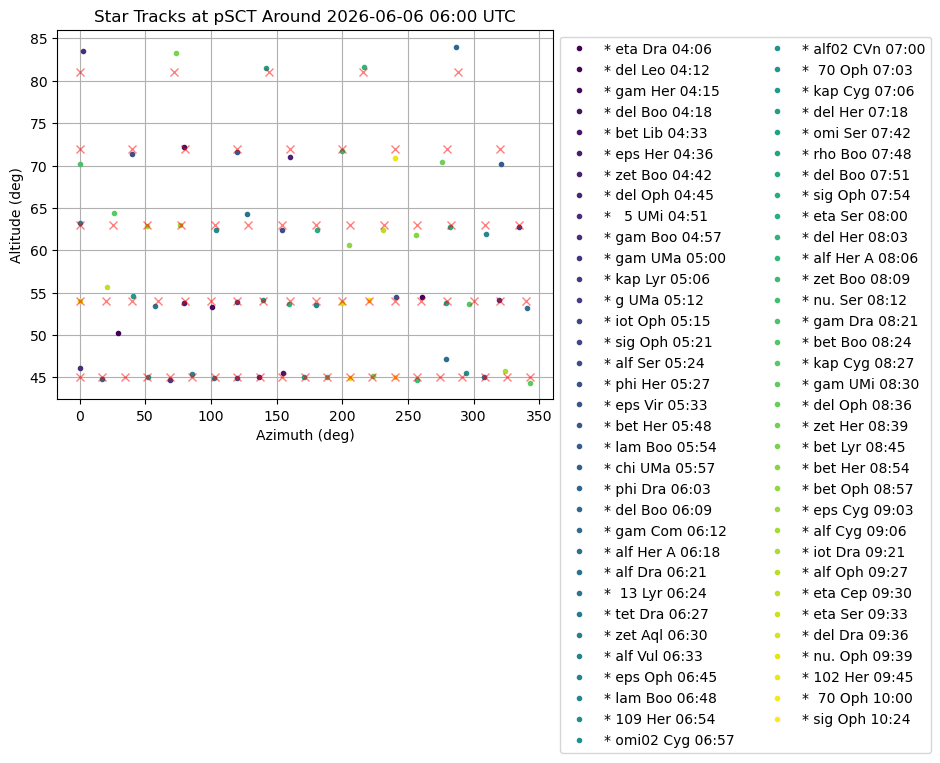

In [156]:
cmap = plt.get_cmap('viridis', len(grid_stars))
for n, star, az_alt, mag, _time in zip(range(len(grid_stars)), grid_stars, grid_az_alts, grid_mags, grid_times):
    az, alt = az_alt
    plt.plot(az, alt, '.', color=cmap(n), label=f'{star} {_time.value[-12:-7]}') #V {mag:.2f} 
for grid_point in grid:
    grid_az, grid_alt = grid_point
    plt.plot(grid_az, grid_alt, 'x', color='r', alpha=0.5)
plt.plot([], [], 'x', color='r', alpha=0.5)#, label='Grid Points')
plt.legend(bbox_to_anchor=(1,1), ncols=2)
#plt.legend()
plt.xlabel('Azimuth (deg)')
plt.ylabel('Altitude (deg)')
plt.title(f'Star Tracks at pSCT Around {date.value[:-7]} UTC')
plt.grid(which='both')
plt.show()

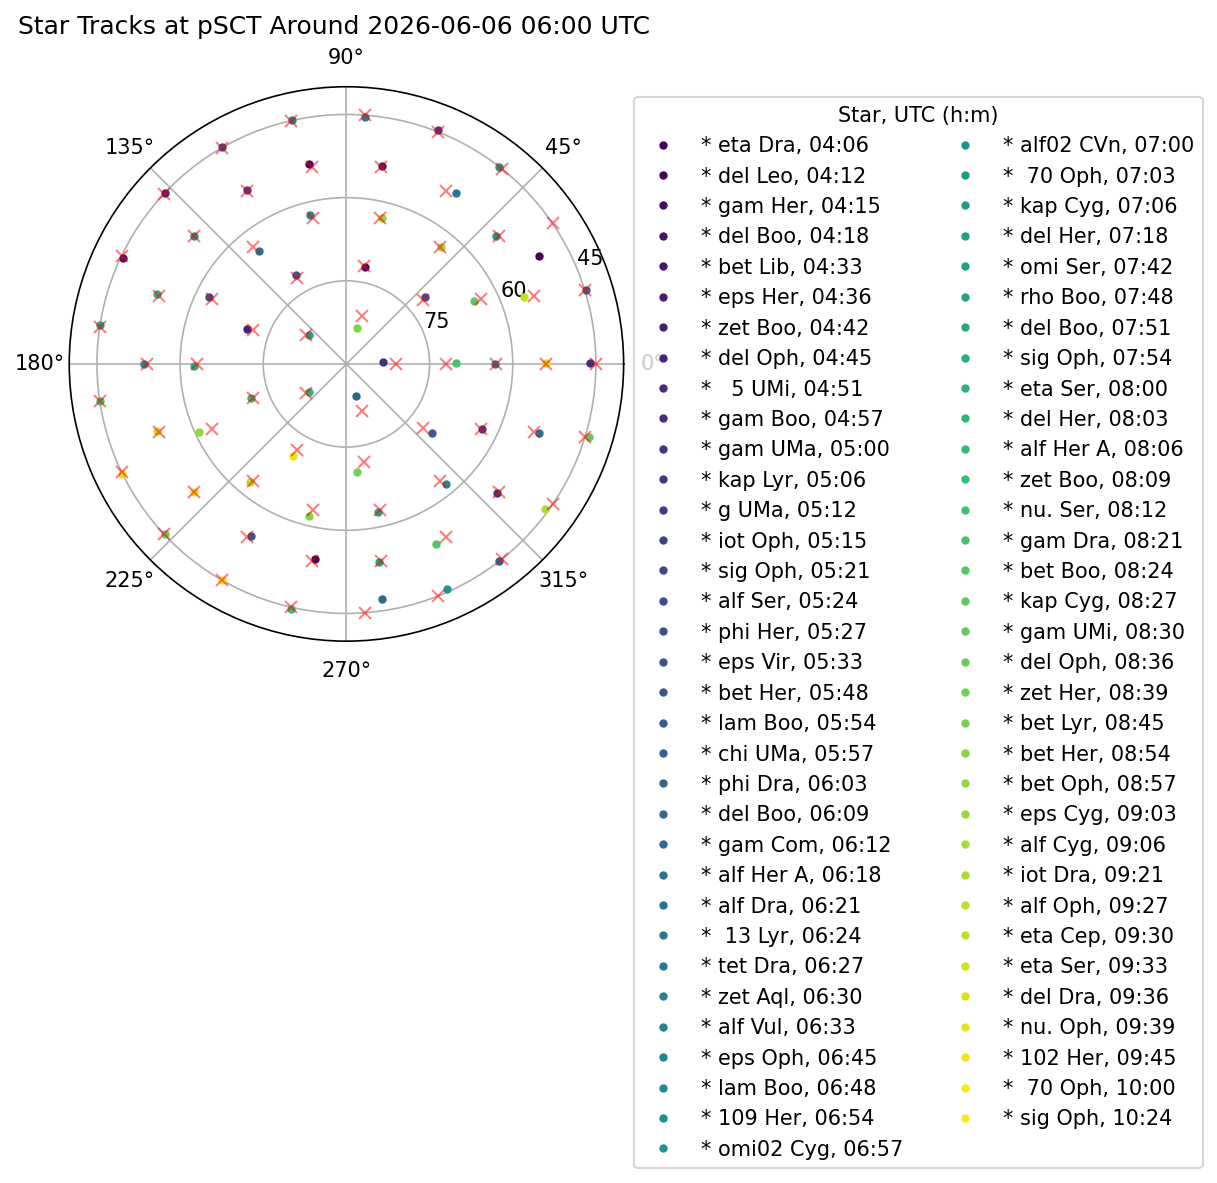

In [157]:
fig, ax = plt.subplots(1, 1, dpi=150, subplot_kw={'projection': 'polar'})

cmap = plt.get_cmap('viridis', len(grid_stars))
for n, star, az_alt, mag, _time in zip(range(len(grid_stars)), grid_stars, grid_az_alts, grid_mags, grid_times):
    az, alt = az_alt
    ax.plot(az*np.pi/180, alt, '.', color=cmap(n), label=f'{star}, {_time.value[-12:-7]}') #V {mag:.2f} 
for grid_point in grid:
    grid_az, grid_alt = grid_point
    ax.plot(grid_az*np.pi/180, grid_alt, 'x', color='r', alpha=0.5)
#ax.plot([], [], 'x', color='r', alpha=0.5, label='Grid Points')
ax.legend(bbox_to_anchor=(1,1), ncols=2, title='Star, UTC (h:m)')
#plt.legend()
#ax.set_philabel('Azimuth (deg)')
ax.set_rlim(90, alt_limit-5)
ax.set_rticks([75, 60, 45])  # Fewer radial ticks
#ax.set_rlabel('Altitude (deg)')
fig.suptitle(f'Star Tracks at pSCT Around {date.value[:-7]} UTC')
plt.show()

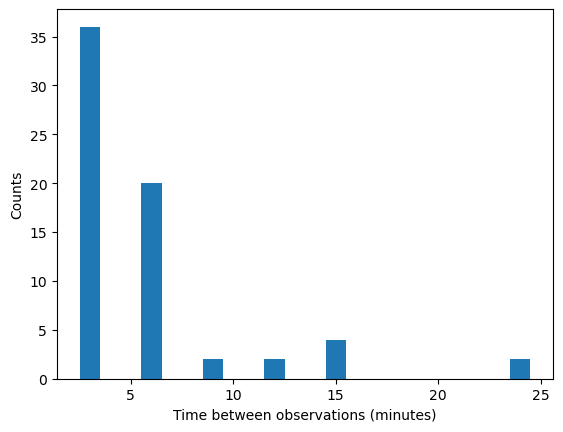

In [188]:
diffs = np.zeros(len(grid_times)-1)
for n in range(len(grid_times)):
    if n == 0:
        continue
    diffs[n-1] = (grid_times[n].mjd - grid_times[n-1].mjd) * 24*60 # in days

plt.hist(diffs, bins=np.arange(np.min(diffs)-0.5, np.max(diffs)+0.5, 1))
plt.xlabel('Time between observations (minutes)')
plt.ylabel('Counts')
plt.show()